In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

TARGET = "Personal Loan"
DROP_COLUMNS = ["ID", "ZIP Code"]
METRICA_PRINCIPAL = "f1_macro"

# Cargar y limpiar datos
df = pd.read_csv("data/raw/dataset.csv")
df['CCAvg'] = df['CCAvg'].astype(str).str.replace('/', '.').astype(float)

X = df.drop(columns=[TARGET] + DROP_COLUMNS)
y = df[TARGET]

# Partición (la prueba queda intocable)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Preprocesador
num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

print("Datos cargados.")

Datos cargados.


In [2]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

models = {
    "logistic": Pipeline([("prep", preprocess), ("model", LogisticRegression(max_iter=2000))]),
    "svm_c1": Pipeline([("prep", preprocess), ("model", SVC(C=1, probability=True, random_state=42))]),
    "svm_c10": Pipeline([("prep", preprocess), ("model", SVC(C=10, probability=True, random_state=42))]),
    "rf_100": Pipeline([("prep", preprocess), ("model", RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1))]),
    "rf_300": Pipeline([("prep", preprocess), ("model", RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1))]),
    "boost": Pipeline([("prep", preprocess), ("model", HistGradientBoostingClassifier(max_depth=6, random_state=42))])
}

print("Creado con éxito.")

Creado con éxito.


In [3]:
from time import perf_counter
from pathlib import Path
import joblib, numpy as np, pandas as pd
from sklearn.metrics import f1_score, recall_score

Path("reports/models").mkdir(parents=True, exist_ok=True)
rows = []

for name, model in models.items():
    fit_times = []
    for repetition in range(3):
        start = perf_counter()
        model.fit(X_train, y_train)
        fit_times.append(perf_counter() - start)
        
    start = perf_counter()
    pred = model.predict(X_test)
    predict_ms = (perf_counter() - start) * 1000
    
    path = Path("reports/models") / f"{name}.joblib"
    joblib.dump(model, path)
    
    rows.append({
        "model": name,
        "f1_macro": f1_score(y_test, pred, average="macro"),
        "recall_macro": recall_score(y_test, pred, average="macro"),
        "fit_median_s": np.median(fit_times),
        "predict_ms": predict_ms,
        "size_kb": path.stat().st_size / 1024
    })

results = pd.DataFrame(rows)
results.sort_values("f1_macro", ascending=False)

c:\Users\lenne\OneDrive\Desktop\Maestria Ciencia de Datos e Inteligencia Artificial\Ciencia de Datos II\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\lenne\OneDrive\Desktop\Maestria Ciencia de Datos e Inteligencia Artificial\Ciencia de Datos II\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\lenne\OneDrive\Desktop\Maestria Ciencia de Datos e Inteligencia Artificial\Ciencia de Datos II\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in ve

,model,f1_macro,recall_macro,fit_median_s,predict_ms,size_kb
5,boost,0.985529,0.983269,0.354961,7.7599,322.205078
3,rf_100,0.976954,0.976954,0.250567,44.2453,1086.963867
4,rf_300,0.974194,0.976401,0.578911,95.8240,3282.901367
2,svm_c10,0.946651,0.934181,0.418783,22.6198,41.240234
1,svm_c1,0.930758,0.894727,0.476638,34.3093,56.630859
0,logistic,0.857627,0.826143,0.017496,4.2061,3.697266


In [4]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

svm_pca = Pipeline([
    ("scale", StandardScaler()),
    ("pca", PCA(n_components=.95, random_state=42)),
    ("model", SVC(C=1, probability=True, random_state=42))
])

svm_pca.fit(X_train, y_train)
print("Componentes:", svm_pca.named_steps["pca"].n_components_)

c:\Users\lenne\OneDrive\Desktop\Maestria Ciencia de Datos e Inteligencia Artificial\Ciencia de Datos II\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Componentes: 9


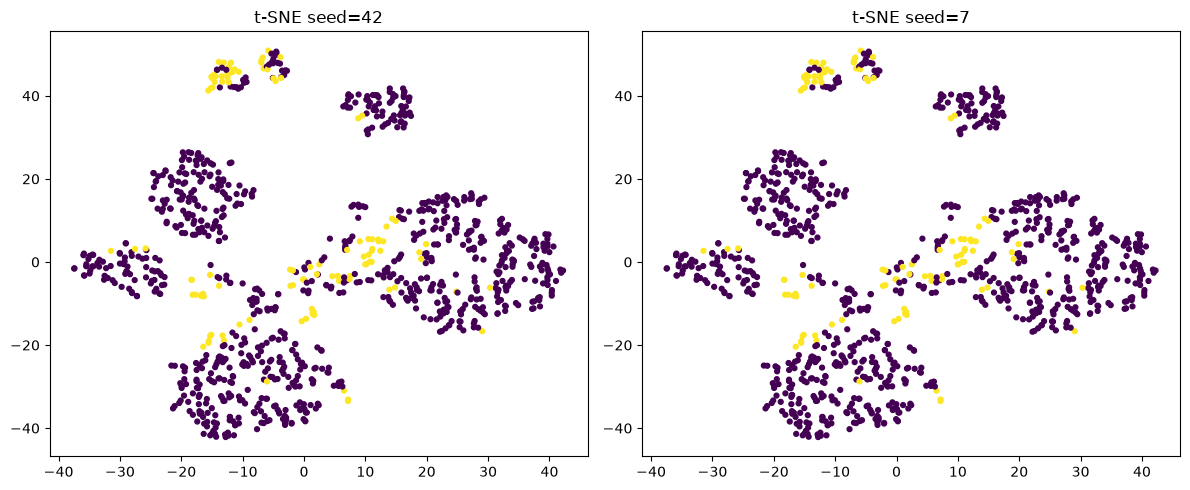

In [5]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

X_num=X.select_dtypes(include="number").fillna(X.select_dtypes(include="number").median())
sample=X_num.sample(min(1000,len(X_num)),random_state=42)
y_sample=y.loc[sample.index]
scaled=StandardScaler().fit_transform(sample)

fig,axes=plt.subplots(1,2,figsize=(12,5))
for ax,seed in zip(axes,[42,7]):
    emb=TSNE(n_components=2,perplexity=30,random_state=seed,init="pca",learning_rate="auto").fit_transform(scaled)
    ax.scatter(emb[:,0],emb[:,1],c=pd.Categorical(y_sample).codes,s=12,cmap="viridis")
    ax.set_title(f"t-SNE seed={seed}")

plt.tight_layout()
plt.savefig("reports/tsne_two_seeds.png",dpi=160)
plt.show()

In [6]:
def pareto_flags(df,score="f1_macro",cost="fit_median_s"):
    flags=[]
    for _,row in df.iterrows():
        dominated=((df[score]>=row[score])&(df[cost]<=row[cost])&
                   ((df[score]>row[score])|(df[cost]<row[cost]))).any()
        flags.append(not bool(dominated))
    return flags

results["is_pareto"]=pareto_flags(results)
results.to_csv("reports/green_ai_results.csv",index=False)
results.sort_values(["is_pareto","f1_macro"],ascending=[False,False])

,model,f1_macro,recall_macro,fit_median_s,predict_ms,size_kb,is_pareto
5,boost,0.985529,0.983269,0.354961,7.7599,322.205078,True
3,rf_100,0.976954,0.976954,0.250567,44.2453,1086.963867,True
0,logistic,0.857627,0.826143,0.017496,4.2061,3.697266,True
4,rf_300,0.974194,0.976401,0.578911,95.8240,3282.901367,False
2,svm_c10,0.946651,0.934181,0.418783,22.6198,41.240234,False
1,svm_c1,0.930758,0.894727,0.476638,34.3093,56.630859,False


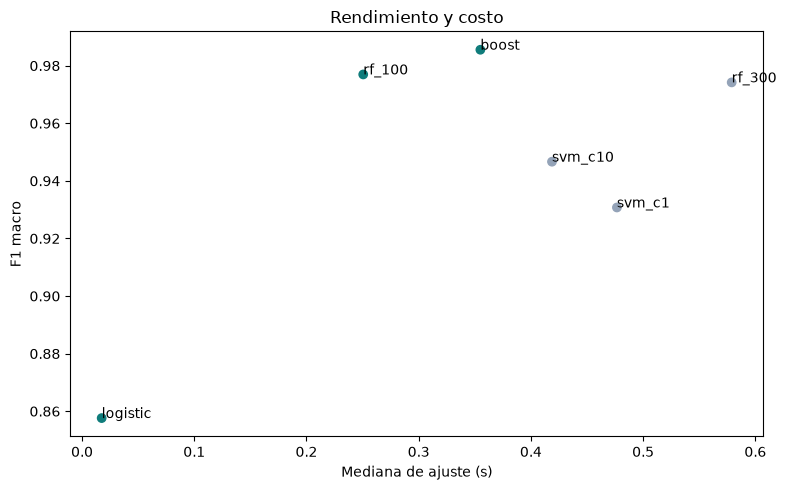

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(results.fit_median_s, results.f1_macro, c=results.is_pareto.map({True:"#0f7c7b", False:"#94a3b8"}))
for _, r in results.iterrows(): 
    ax.annotate(r.model, (r.fit_median_s, r.f1_macro))
ax.set(xlabel="Mediana de ajuste (s)", ylabel="F1 macro", title="Rendimiento y costo")
plt.tight_layout()
plt.savefig("reports/pareto.png", dpi=160)
plt.show()

# Análisis de Decisión y Green AI: Frontera de Pareto

El análisis de la frontera de Pareto nos permite tomar una decisión informada basada en los principios de Green AI, equilibrando el poder predictivo con la eficiencia computacional. Al evaluar el catálogo de modelos, el **máximo F1-Score macro** fue alcanzado por el ensamble HistGradientBoosting (`boost`), registrando un sobresaliente **0.985** , lo cual representa una capacidad casi perfecta para identificar a los prospectos bancarios viables.

Como **alternativa seleccionada**, elegimos definitivamente el modelo **`boost`**. Aunque la Regresión Logística (`logistic`) demostró ser la más rápida (0.017 segundos en entrenamiento)[cite: 42], su penalidad en el rendimiento (F1 de 0.857) es muy alta para los objetivos de conversión del banco. Al contrastar nuestra nueva selección contra la Máquina de Vectores de Soporte estándar utilizada en laboratorios previos (`svm_c1`), el ensamble `boost` presenta una **diferencia absoluta de F1** de **+0.054** a su favor (0.985 frente a 0.930).

En términos de eficiencia y consumo, el modelo seleccionado demuestra ser categóricamente superior. Frente al `svm_c1`, el `boost` presenta un **porcentaje de ahorro temporal** en el ajuste de aproximadamente **25%**, reduciendo la mediana de entrenamiento de 0.47 segundos a tan solo 0.35 segundos. Entregar mejores predicciones en menos tiempo es el núcleo de la sostenibilidad algorítmica.

Al analizar la **diferencia de tamaño** en disco (un factor crítico para el despliegue en producción y el consumo de RAM), el modelo `boost` ocupa **322 KB**[cite: 42]. Si bien es marginalmente más pesado que la SVM (56 KB), es abismalmente más ligero que los ensambles basados en Random Forest. Por ejemplo, el `rf_300` exige **3.2 MB** de espacio (3282 KB) y el `rf_100` supera el megabyte (1086 KB), ofreciendo ambos un desempeño predictivo inferior y un mayor costo ecológico y de almacenamiento.

En cuanto a las **limitaciones y contexto del hardware**, es importante destacar que estas métricas fueron evaluadas en un entorno de procesamiento local estándar. Los tiempos de entrenamiento por debajo del segundo y las inferencias ultrarrápidas de milisegundos demuestran que, para matrices tabulares de este volumen, arquitecturas optimizadas como HistGradientBoosting no requieren costosa aceleración por GPU. Las fluctuaciones naturales en los procesos de fondo de la CPU se mitigaron utilizando la mediana de tres mediciones[cite: 43], validando que la eficiencia del modelo es intrínseca a su diseño y directamente aplicable a infraestructuras de bajo consumo.

In [8]:
import platform, sys, sklearn
print("Python", sys.version)
print("Sistema", platform.platform())
print("Procesador", platform.processor())
print("scikit-learn", sklearn.__version__)

Python 3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]
Sistema Windows-11-10.0.26200-SP0
Procesador Intel64 Family 6 Model 154 Stepping 3, GenuineIntel
scikit-learn 1.9.1
